# LCA model 

- Collect user inputs 
- Calculate environmental impact with LCA 
- Display results 

## User inputs 

In [20]:
import pandas as pd 

df_unit_burdens = pd.read_csv("../../data/processed/unit_burdens.csv")
df_unit_benefit_params = pd.read_csv("../../data/processed/unit_benefit_params.csv")

burden_options = df_unit_burdens.material_name.unique()
benefit_options = df_unit_benefit_params.material_name.unique()

print(f"Loaded {len(burden_options)} burden options and {len(benefit_options)} benefit options.")
print(f"Burden options: {burden_options}")
print(f"Benefit options: {benefit_options}")

Loaded 50 burden options and 13 benefit options.
Burden options: ['Peas' 'Cotton fiber' 'Hemp fiber' 'Kenaf fiber' 'Jute fiber'
 'Grass fiber' 'Bark chips' 'Sawdust' 'Wood (hard wood, raw)'
 'Wood (soft wood, raw)' 'Mechanical fastener (screws, nails, brackets)'
 'Wood glue' 'Fiber glue (epoxy resin)' 'Cement' 'Lime' 'Concrete' 'Steel'
 'Road transport' 'Pea protein binder' 'Industrial machine (wear)'
 'Electricity (AT)' 'Electricity (BE)' 'Electricity (BG)'
 'Electricity (HR)' 'Electricity (CY)' 'Electricity (CZ)'
 'Electricity (DK)' 'Electricity (EE)' 'Electricity (FI)'
 'Electricity (FR)' 'Electricity (DE)' 'Electricity (GR)'
 'Electricity (HU)' 'Electricity (IE)' 'Electricity (IT)'
 'Electricity (LV)' 'Electricity (LT)' 'Electricity (LU)'
 'Electricity (MT)' 'Electricity (NL)' 'Electricity (PL)'
 'Electricity (PT)' 'Electricity (RO)' 'Electricity (SK)'
 'Electricity (SI)' 'Electricity (ES)' 'Electricity (SE)'
 'Electricity (GB)' 'Electricity (CH)' 'Electricity (NO)']
Benefit option

### Bill of materials

Composition given as percentages of the input mass at each stage — production and repair each have their own BOM, since repair material can have a different mix. `allocation_type` drives whether a material's own burden or the shared transport burden gets used later.

In [21]:
from dataclasses import dataclass
from typing import Optional, List

@dataclass
class BOMItem:
    material_name: str
    percentage: float      # share of total input mass at this stage — all items in one BOM should sum to 100
    allocation_type: str   # "product" / "waste" / "wild-harvested"

def check_bom(bom: List[BOMItem], label: str, tol: float = 0.01):
    total = sum(item.percentage for item in bom)
    if abs(total - 100) > tol:
        raise ValueError(f"{label} BOM percentages sum to {total}, not 100")
    print(f"{label} BOM: {len(bom)} materials, {total:.1f}%")


# ── Production BOM — 3D-printed biopolymer panel ──────────────────────────────
production_bom = [
    BOMItem("Pea protein binder", 70, "product"),
    BOMItem("Sawdust",            20, "waste"),
    BOMItem("Seagrass",           10, "wild-harvested"),
]
check_bom(production_bom, "Production")

# ── Repair BOM — different mix, replaces part of the product ──────────────────
repair_bom = [
    BOMItem("Pea protein binder", 80, "product"),
    BOMItem("Seagrass",           10, "wild-harvested"),
    BOMItem("Hemp fiber",         10, "product"),
]
check_bom(repair_bom, "Repair")

Production BOM: 3 materials, 100.0%
Repair BOM: 3 materials, 100.0%


### Production process chain 

ordered steps, each with its own machine/energy parameters and electricity location; `retained_pct` is the share of mass carried into the next step — only the last step in a chain omits it, since it produces the target output directly

In [22]:
@dataclass
class ProcessStep:
    step_name: str
    kg_machine: float
    power_kW: float
    rate_kg_per_hr: float
    machine_lifetime_hrs: float
    electricity_location: str
    retained_pct: float  # % of mass retained after this step, including the last one


# ── Production chain — mixing → 3D printing → baking ──────────────────────────
production_chain = [
    ProcessStep("Mixing",     kg_machine=80,  power_kW=1.5, rate_kg_per_hr=15.0,
                machine_lifetime_hrs=15000, electricity_location="NL", retained_pct=98),
    ProcessStep("3D printing", kg_machine=250, power_kW=2.5, rate_kg_per_hr=0.5,
                machine_lifetime_hrs=20000, electricity_location="NL", retained_pct=92),
    ProcessStep("Baking",     kg_machine=500, power_kW=8.0, rate_kg_per_hr=4.0,
                machine_lifetime_hrs=25000, electricity_location="NL", retained_pct=30),  # evaporation loss
]

product_kg = 1.0
print(f"Production chain: {len(production_chain)} steps → target output {product_kg} kg")

Production chain: 3 steps → target output 1.0 kg


### Repair

repairs use their own (shorter) chain — no baking, since repairs dry on-site — and their own BOM; `repair_material_kg` is the mass added per repair event, expressed as a share of the product mass

In [23]:
# ── Repair chain — mixing → 3D printing, no baking (dries on-site) ────────────
repair_chain = [
    ProcessStep("Mixing",      kg_machine=80,  power_kW=1.5, rate_kg_per_hr=15.0,
                machine_lifetime_hrs=15000, electricity_location="NL", retained_pct=98),
    ProcessStep("3D printing", kg_machine=250, power_kW=2.5, rate_kg_per_hr=0.5,
                machine_lifetime_hrs=20000, electricity_location="NL", retained_pct=92),
]

repair_material_kg = 0.10 * product_kg  # each repair event replaces 10% of the product

expected_lifetime_yr = 20
lifetime_extension_per_repair_yr = 10
number_of_repair_events = 3

print(f"Repair chain: {len(repair_chain)} steps → {repair_material_kg} kg per event")
print(f"Lifetime: {expected_lifetime_yr} yr, +{lifetime_extension_per_repair_yr} yr × {number_of_repair_events} repairs "
      f"= {expected_lifetime_yr + lifetime_extension_per_repair_yr * number_of_repair_events} yr total")

Repair chain: 2 steps → 0.1 kg per event
Lifetime: 20 yr, +10 yr × 3 repairs = 50 yr total


## LCA calculation 

Calculate environmental impact based on 
- user inputs
- pre-calculated environmental data, see `01_dataPrep.ipynb`

### Burdens

Burdens come from three sources: the materials that go into the product, the
production process that assembles it, and any repair events over its lifetime.

#### Load pre-calculated unit data 

Loads `unit_burdens.csv` and sets up two helpers used by every burden calculation
below: `get_unit_burden()` looks up a single material/process's burden vector across
all EF v3.1 categories, and `get_material_unit_burden()` additionally applies the
allocation-type substitution — non-"product" materials borrow the shared
`Road transport` burden instead of their own row, same logic as `01_dataPrep.ipynb`.

In [24]:
import pandas as pd

OUTPUT_DIR = "../../data/processed"  # adjust to match your repo structure

df_burdens = pd.read_csv(f"{OUTPUT_DIR}/unit_burdens.csv")
CATEGORIES = df_burdens["impact_category"].unique().tolist()
TRANSPORT_MATERIAL_NAME = "Road transport"

def get_unit_burden(name):
    """Burden (all EF v3.1 categories) per unit of `name`, indexed by impact_category."""
    rows = df_burdens[df_burdens["material_name"] == name]
    if rows.empty:
        raise ValueError(f"No burden data for '{name}'")
    return rows.set_index("impact_category")["score"]

def get_material_unit_burden(material_name, allocation_type):
    """Same as get_unit_burden(), but substitutes the shared transport burden for
    non-'product' allocations (waste / wild-harvested materials)."""
    lookup_name = material_name if allocation_type == "product" else TRANSPORT_MATERIAL_NAME
    return get_unit_burden(lookup_name)

print(f"Loaded unit burdens: {df_burdens['material_name'].nunique()} materials/processes × {len(CATEGORIES)} categories")

Loaded unit burdens: 50 materials/processes × 25 categories


#### Material burdens

Burden of the raw materials feeding the production chain. Since the bill of
materials is percentage-based and the process chain is solved backward from a
target output (see `#### Production burdens` below), this depends on
`total_input_kg` — the actual mass required at the first production step — which
is why material burdens are computed *after* solving the chain, not before.

In [25]:
def compute_material_burdens(bom, total_input_kg):
    """Total burden (all categories) for a BOM, given the total input mass it represents."""
    total = pd.Series(0.0, index=CATEGORIES)
    for item in bom:
        kg = total_input_kg * item.percentage / 100
        unit_burden = get_material_unit_burden(item.material_name, item.allocation_type)
        total = total.add(unit_burden * kg, fill_value=0.0)
    return total

#### Production burdens

Solves the process chain backward from `product_kg` (same logic as the HTML tool):
the last step's required input equals the target output directly; each earlier
step's required input is back-calculated from the next step's requirement, divided
by its own `retained_pct`. Machine wear and energy use are then computed per step
from that required throughput, and converted to impacts via the machine-wear and
location-specific electricity unit burdens.

In [26]:
def compute_process_burdens(chain, target_output_kg):
    """
    Solves a process chain backward from `target_output_kg`, and returns:
      total    — combined burden (all categories) across every step
      df_steps — per-step required_input_kg / process_time_hrs / machine_wear_kg / energy_use_kwh
    """
    n = len(chain)
    required_input_kg = [None] * n
    next_required = target_output_kg

    for i in range(n - 1, -1, -1):
        step = chain[i]
        required_input_kg[i] = next_required / (step.retained_pct / 100)
        next_required = required_input_kg[i]

    total = pd.Series(0.0, index=CATEGORIES)
    step_rows = []

    for i, step in enumerate(chain):
        process_time_hrs = required_input_kg[i] / step.rate_kg_per_hr
        machine_wear_kg = step.kg_machine * (process_time_hrs / step.machine_lifetime_hrs)
        energy_use_kwh = step.power_kW * process_time_hrs

        machine_burden = get_unit_burden("Industrial machine (wear)") * machine_wear_kg
        electricity_burden = get_unit_burden(f"Electricity ({step.electricity_location})") * energy_use_kwh

        total = total.add(machine_burden, fill_value=0.0).add(electricity_burden, fill_value=0.0)
        step_rows.append({
            "step_name": step.step_name, "required_input_kg": required_input_kg[i],
            "process_time_hrs": process_time_hrs,
            "machine_wear_kg": machine_wear_kg, "energy_use_kwh": energy_use_kwh,
        })

    return total, pd.DataFrame(step_rows)


production_process_burdens, df_production_steps = compute_process_burdens(production_chain, product_kg)
total_material_input_kg = df_production_steps["required_input_kg"].iloc[0]

material_burdens = compute_material_burdens(production_bom, total_material_input_kg)

print(f"Total raw material input required: {total_material_input_kg:.3f} kg (for {product_kg} kg product)")
df_production_steps

Total raw material input required: 3.697 kg (for 1.0 kg product)


,step_name,required_input_kg,process_time_hrs,machine_wear_kg,energy_use_kwh
0,Mixing,3.697131,0.246475,0.001315,0.369713
1,3D printing,3.623188,7.246377,0.090580,18.115942
2,Baking,3.333333,0.833333,0.016667,6.666667


#### Repair burdens 

Same chain-solving and material-burden logic as production, applied to the repair
BOM and repair chain, then scaled by `number_of_repair_events` — since each event
consumes the same repair material and process burden.

In [64]:
repair_process_burdens_per_event, df_repair_steps = compute_process_burdens(repair_chain, repair_material_kg)
repair_material_input_kg = df_repair_steps["required_input_kg"].iloc[0]

repair_material_burdens_per_event = compute_material_burdens(repair_bom, repair_material_input_kg)

repair_burdens = (
    (repair_process_burdens_per_event + repair_material_burdens_per_event) * number_of_repair_events
)

print(f"Repair material input per event: {repair_material_input_kg:.3f} kg (for {repair_material_kg} kg replaced)")
print(f"Total across {number_of_repair_events} repair events")
df_repair_steps

Repair material input per event: 0.111 kg (for 0.1 kg replaced)
Total across 3 repair events


,step_name,required_input_kg,process_time_hrs,machine_wear_kg,energy_use_kwh
0,Mixing,0.110914,0.007394,0.000039,0.011091
1,3D printing,0.108696,0.217391,0.002717,0.543478


#### Total burdens

Sum of material, production, and repair burdens — the full-lifecycle burden side of
the result, before any carbon sequestration credit is applied.

In [28]:
total_burdens = material_burdens.add(production_process_burdens, fill_value=0.0).add(repair_burdens, fill_value=0.0)

print("Total burdens by source (climate change category, kg CO2-eq):")
print(f"  Material:   {material_burdens['climate change']:.4f}")
print(f"  Production: {production_process_burdens['climate change']:.4f}")
print(f"  Repair:     {repair_burdens['climate change']:.4f}")
print(f"  TOTAL:      {total_burdens['climate change']:.4f}")

Total burdens by source (climate change category, kg CO2-eq):
  Material:   1.4379
  Production: 11.1870
  Repair:     0.9171
  TOTAL:      13.5421


### Benefits (carbon sequestration)

Two mechanisms, both operating on the same `carbon_content_kgC_per_kg` data —
which one applies to a given material is determined by its `allocation_type`,
already set per BOM item:

- `allocation_type == "product"` → carbon sequestration from plant growth
  (GWP_bio, Guest et al. 2012) — this system is responsible for the material's
  cultivation, so it gets credit for the growth itself.
- `allocation_type in ("waste", "wild-harvested")` → carbon sequestration from
  avoided emissions (dynamic CF, Levasseur et al. 2010) — this system isn't
  responsible for the material's growth, only for delaying a release that would
  have happened anyway.

This mirrors `eligibility_for_allocation()` from `01_materials_module.ipynb`
Section 5.3 — same rule, just reused here.

#### Load unit benefit params

`carbon_content_kgC_per_kg` and `rotation_period_yr` per material, from
`unit_benefit_params.csv`.

In [29]:
df_benefit_params = df_unit_benefit_params.set_index("material_name")

def get_benefit_params(material_name):
    """(carbon_content_kgC_per_kg, rotation_period_yr) for a material."""
    if material_name not in df_benefit_params.index:
        raise ValueError(f"No benefit params for '{material_name}'")
    row = df_benefit_params.loc[material_name]
    return row["carbon_content_kgC_per_kg"], row["rotation_period_yr"]

print(f"Loaded benefit params for {len(df_benefit_params)} materials")
df_benefit_params[["carbon_content_kgC_per_kg", "rotation_period_yr"]]

Loaded benefit params for 13 materials


,carbon_content_kgC_per_kg,rotation_period_yr
material_name,,
Peas,0.407697,1.0
Cotton fiber,0.438425,1.0
Hemp fiber,0.445704,1.0
Kenaf fiber,0.418944,1.0
Jute fiber,0.404396,1.0
Grass fiber,0.450340,1.0
Bark chips,0.205833,80.0
Sawdust,0.290588,80.0
"Wood (hard wood, raw)",0.290588,100.0


#### Storage periods

Carbon sequestration credit depends on how long the carbon stays stored, which
differs for production material vs. each repair event:

- Production material — stored for the product's full lifespan, including all
  repair-driven extensions: `expected_lifetime_yr + lifetime_extension_per_repair_yr × number_of_repair_events`.
- Repair event *i*'s material — added partway through the product's life, so
  it's stored for less time. Assuming repairs happen sequentially, each exactly
  when the previous life stage would otherwise have ended, repair event *i*
  (1-indexed) is stored for `(number_of_repair_events − i + 1) × lifetime_extension_per_repair_yr`.

  For our example (3 repairs × 10 yr extension): repair 1 → 30 yr stored,
  repair 2 → 20 yr, repair 3 → 10 yr.

In [30]:
production_storage_yr = expected_lifetime_yr + lifetime_extension_per_repair_yr * number_of_repair_events

repair_storage_yr = [
    (number_of_repair_events - i + 1) * lifetime_extension_per_repair_yr
    for i in range(1, number_of_repair_events + 1)
]

print(f"Production material storage period: {production_storage_yr} yr")
print(f"Repair event storage periods:       {repair_storage_yr} yr  (event 1 → event {number_of_repair_events})")

Production material storage period: 50 yr
Repair event storage periods:       [30, 20, 10] yr  (event 1 → event 3)


#### GWP_bio and dynamic CF functions

Ported directly from `03_LifeCycleImpactAssessment_benefits.ipynb` — same
Guest et al. (2012) lookup table and Levasseur et al. (2010) Bern-model DCF.

In [31]:
import numpy as np

# ── GWP_bio lookup table — Guest et al. (2012), Table 1, 100-yr TH ────────────
ROTATION_PERIODS = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
STORAGE_PERIODS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

GWPBIO_TABLE = {
     1:   [ 0.00, -0.07, -0.15, -0.23, -0.32, -0.40, -0.50, -0.60, -0.71, -0.84, -0.99],
    10:   [ 0.04, -0.04, -0.12, -0.20, -0.28, -0.37, -0.46, -0.57, -0.68, -0.80, -0.96],
    20:   [ 0.08,  0.00, -0.08, -0.16, -0.24, -0.33, -0.42, -0.53, -0.64, -0.76, -0.92],
    30:   [ 0.12,  0.04, -0.04, -0.12, -0.20, -0.29, -0.38, -0.48, -0.60, -0.72, -0.88],
    40:   [ 0.16,  0.09,  0.01, -0.08, -0.16, -0.25, -0.34, -0.44, -0.55, -0.68, -0.84],
    50:   [ 0.20,  0.13,  0.05, -0.03, -0.12, -0.21, -0.30, -0.40, -0.51, -0.64, -0.80],
    60:   [ 0.25,  0.17,  0.09,  0.01, -0.07, -0.16, -0.26, -0.36, -0.47, -0.59, -0.75],
    70:   [ 0.29,  0.22,  0.14,  0.06, -0.03, -0.12, -0.21, -0.31, -0.42, -0.55, -0.71],
    80:   [ 0.34,  0.26,  0.18,  0.10,  0.02, -0.07, -0.17, -0.27, -0.38, -0.50, -0.66],
    90:   [ 0.38,  0.31,  0.23,  0.15,  0.06, -0.03, -0.12, -0.22, -0.33, -0.46, -0.62],
   100:   [ 0.44,  0.37,  0.29,  0.21,  0.12,  0.032,-0.06, -0.16, -0.27, -0.40, -0.56],
}

def lookup_gwpbio(rotation_yr, storage_yr):
    """GWP_bio factor, linearly interpolated between 10-yr storage columns.
    rotation_yr is snapped to the nearest defined row if not an exact match."""
    nearest_rotation = min(GWPBIO_TABLE, key=lambda r: abs(r - rotation_yr))
    row = GWPBIO_TABLE[nearest_rotation]

    storage_yr = max(0, min(storage_yr, STORAGE_PERIODS[-1]))  # clip to table range
    if storage_yr % 10 == 0:
        return row[STORAGE_PERIODS.index(int(storage_yr))]

    lo = int(storage_yr // 10) * 10
    hi = lo + 10
    frac = (storage_yr - lo) / 10
    return row[STORAGE_PERIODS.index(lo)] * (1 - frac) + row[STORAGE_PERIODS.index(hi)] * frac


# ── Dynamic characterization factor (Levasseur et al., 2010) ─────────────────
# Bern carbon cycle model coefficients (Forster et al., 2007, via Levasseur et al. eq 3)
BERN_A = [0.217, 0.259, 0.338, 0.186]
BERN_TAU = [None, 172.9, 18.51, 1.186]  # tau_0 unused (a0 term has no decay)

def agwp_integral(t):
    """Integral of the Bern CO2 atmospheric load C(t') from 0 to t.
    Proportional to AGWP(t) — the radiative efficiency constant cancels
    out when DCF is computed as a ratio, so it's omitted here."""
    a0, a1, a2, a3 = BERN_A
    _, tau1, tau2, tau3 = BERN_TAU
    return (
        a0 * t
        + a1 * tau1 * (1 - np.exp(-t / tau1))
        + a2 * tau2 * (1 - np.exp(-t / tau2))
        + a3 * tau3 * (1 - np.exp(-t / tau3))
    )

def dynamic_cf(tau_storage, T=100):
    """Dynamic characterization factor for a CO2 pulse delayed by tau_storage
    years, evaluated over a fixed time horizon T (default 100 yr)."""
    return agwp_integral(T - tau_storage) / agwp_integral(T)


print(f"GWP_bio(rotation=1, storage=50):   {lookup_gwpbio(1, 50):.4f}")
print(f"Dynamic CF(storage=30, horizon=100): {dynamic_cf(30):.4f}")

GWP_bio(rotation=1, storage=50):   -0.4000
Dynamic CF(storage=30, horizon=100): 0.7619


#### Carbon sequestration from plant growth

For every BOM item (production + each repair event) with `allocation_type == "product"`:
`credit = carbon_content_kgC_per_kg × kg_material × 44/12 × GWP_bio(rotation_yr, storage_yr)`

In [32]:
MOLAR_RATIO = 44 / 12  # kg CO2 per kg C

def compute_sequestration_credit(bom, total_kg, storage_yr):
    """Sum of GWP_bio sequestration credit across a BOM's 'product'-allocated items."""
    total = 0.0
    for item in bom:
        if item.allocation_type != "product":
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, rotation_yr = get_benefit_params(item.material_name)
        gwp = lookup_gwpbio(rotation_yr, storage_yr)
        total += carbon_content * kg * MOLAR_RATIO * gwp
    return total


production_sequestration = compute_sequestration_credit(
    production_bom, total_material_input_kg, production_storage_yr
)

repair_sequestration = sum(
    compute_sequestration_credit(repair_bom, repair_material_input_kg, storage_yr)
    for storage_yr in repair_storage_yr
)

sequestration_growth = production_sequestration + repair_sequestration

print(f"Production material sequestration credit: {production_sequestration:.4f} kg CO2-eq")
print(f"Repair material sequestration credit:      {repair_sequestration:.4f} kg CO2-eq")
print(f"Total (plant growth):                      {sequestration_growth:.4f} kg CO2-eq")

Production material sequestration credit: -1.0065 kg CO2-eq
Repair material sequestration credit:      -0.0470 kg CO2-eq
Total (plant growth):                      -1.0535 kg CO2-eq


#### Carbon sequestration from avoided emissions

For every BOM item with `allocation_type in ("waste", "wild-harvested")`:
`credit = carbon_content_kgC_per_kg × kg_material × 44/12 × (DCF(storage_yr, 100) − 1)`

In [33]:
def compute_delayed_emissions_credit(bom, total_kg, storage_yr):
    """Sum of dynamic-CF delayed-emissions credit across a BOM's waste/wild-harvested items."""
    total = 0.0
    for item in bom:
        if item.allocation_type not in ("waste", "wild-harvested"):
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, _ = get_benefit_params(item.material_name)
        dcf = dynamic_cf(storage_yr)
        total += carbon_content * kg * MOLAR_RATIO * (dcf - 1)
    return total


production_delayed_emissions = compute_delayed_emissions_credit(
    production_bom, total_material_input_kg, production_storage_yr
)

repair_delayed_emissions = sum(
    compute_delayed_emissions_credit(repair_bom, repair_material_input_kg, storage_yr)
    for storage_yr in repair_storage_yr
)

sequestration_avoided_emissions = production_delayed_emissions + repair_delayed_emissions

print(f"Production material delayed-emissions credit: {production_delayed_emissions:.4f} kg CO2-eq")
print(f"Repair material delayed-emissions credit:      {repair_delayed_emissions:.4f} kg CO2-eq")
print(f"Total (avoided emissions):                     {sequestration_avoided_emissions:.4f} kg CO2-eq")

Production material delayed-emissions credit: -0.5113 kg CO2-eq
Repair material delayed-emissions credit:      -0.0064 kg CO2-eq
Total (avoided emissions):                     -0.5177 kg CO2-eq


#### Total benefits

Sum of both credit mechanisms — climate change category only, same as the
reference notebook (neither mechanism has a defined credit in any other EF v3.1
category).

In [34]:
total_benefits = pd.Series(0.0, index=CATEGORIES)
total_benefits["climate change"] = sequestration_growth + sequestration_avoided_emissions

print("Total benefits by mechanism (climate change category, kg CO2-eq):")
print(f"  Plant growth (GWP_bio):        {sequestration_growth:.4f}")
print(f"  Avoided emissions (dynamic CF): {sequestration_avoided_emissions:.4f}")
print(f"  TOTAL:                          {total_benefits['climate change']:.4f}")

Total benefits by mechanism (climate change category, kg CO2-eq):
  Plant growth (GWP_bio):        -1.0535
  Avoided emissions (dynamic CF): -0.5177
  TOTAL:                          -1.5712


## Results 

### EU normalization factors 

EF v3.1 global per-capita normalisation factors (EC-JRC, 2010 baseline), same
category set as `EF_UNITS`. Sub-category flows (biogenic/fossil climate change,
organics/inorganics splits) share their parent category's factor, since EF only
defines normalisation at the 16 top-level category level.

In [35]:
EF_NORMALISATION = {
    'climate change':                                     8.10e+03,
    'climate change: biogenic':                           8.10e+03,
    'climate change: fossil':                              8.10e+03,
    'climate change: land use and land use change':        8.10e+03,
    'ecotoxicity: freshwater':                             4.27e+04,
    'ecotoxicity: freshwater, inorganics':                 4.27e+04,
    'ecotoxicity: freshwater, organics':                   4.27e+04,
    'energy resources: non-renewable':                     6.50e+04,
    'eutrophication: freshwater':                          1.61e+00,
    'eutrophication: marine':                              1.95e+01,
    'eutrophication: terrestrial':                         1.77e+02,
    'human toxicity: carcinogenic':                        1.72e-05,
    'human toxicity: carcinogenic, inorganics':            1.72e-05,
    'human toxicity: carcinogenic, organics':              1.72e-05,
    'human toxicity: non-carcinogenic':                    2.30e-04,
    'human toxicity: non-carcinogenic, inorganics':        2.30e-04,
    'human toxicity: non-carcinogenic, organics':          2.30e-04,
    'ionising radiation: human health':                    4.22e+03,
    'land use':                                            8.19e+05,
    'material resources: metals/minerals':                 6.36e-02,
    'ozone depletion':                                     5.36e-02,
    'particulate matter formation':                        5.95e-04,
    'photochemical oxidant formation: human health':       4.06e+01,
    'water use':                                           1.15e+04,
    'acidification':                                       5.56e+01,
}

missing_nf = [c for c in CATEGORIES if c not in EF_NORMALISATION]
if missing_nf:
    print(f"⚠ {len(missing_nf)} categories have no normalisation factor: {missing_nf}")
else:
    print(f"All {len(CATEGORIES)} categories have a normalisation factor.")

All 25 categories have a normalisation factor.


### GWP100 — burden, benefit, and net impact

Horizontal bar chart: total burden, total benefit, and their sum (net impact),
all in the `climate change` category (kg CO2-eq).

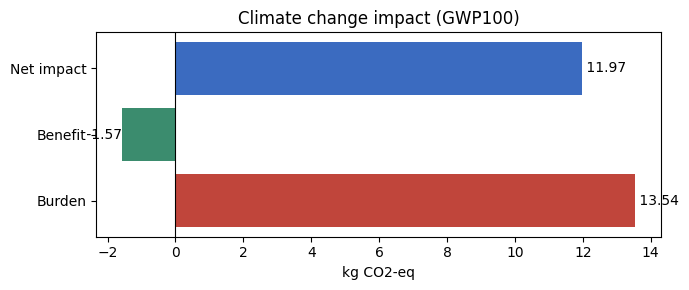

In [36]:
import matplotlib.pyplot as plt

gwp_burden = total_burdens["climate change"]
gwp_benefit = total_benefits["climate change"]
gwp_net = gwp_burden + gwp_benefit

labels = ["Burden", "Benefit", "Net impact"]
values = [gwp_burden, gwp_benefit, gwp_net]
colors = ["#C0453B", "#3B8C6E", "#3B6BC0"]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(labels, values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("kg CO2-eq")
ax.set_title("Climate change impact (GWP100)")
for i, v in enumerate(values):
    ax.text(v, i, f" {v:.2f}", va="center", ha="left" if v >= 0 else "right")

plt.tight_layout()
plt.show()

### All burdens, EU normalised

Horizontal bar chart, one bar per EF v3.1 category, burdens only (no benefits),
normalised against EU per-capita factors so categories with very different
native units become comparable. Sorted by magnitude.

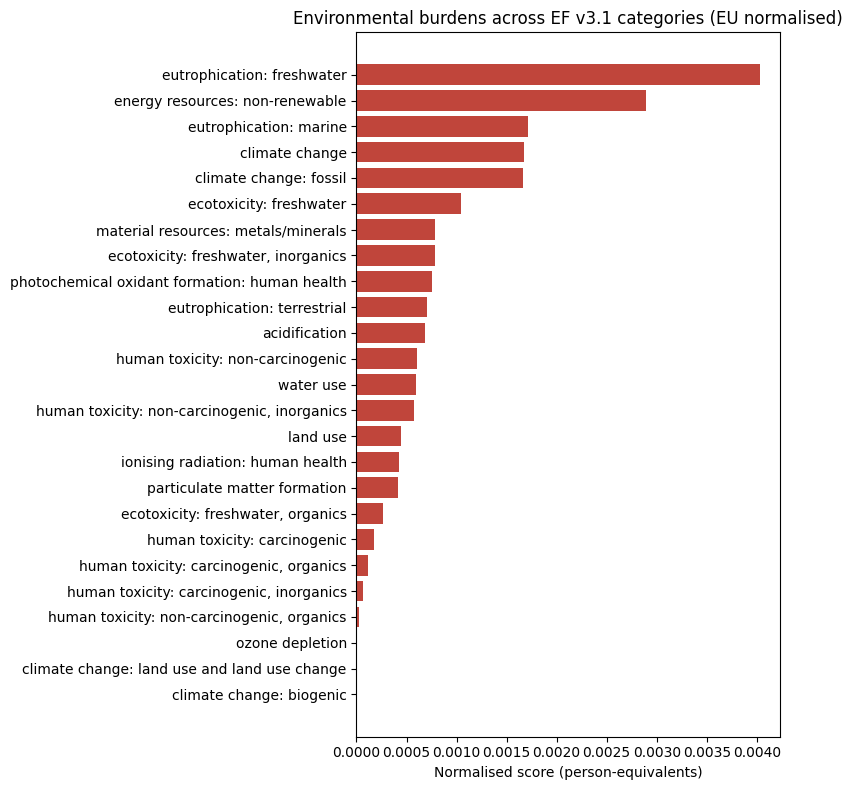

In [37]:
normalised_burdens = (total_burdens / pd.Series(EF_NORMALISATION)).dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(normalised_burdens.index, normalised_burdens.values, color="#C0453B")
ax.set_xlabel("Normalised score (person-equivalents)")
ax.set_title("Environmental burdens across EF v3.1 categories (EU normalised)")
plt.tight_layout()
plt.show()

### Breakdown — burdens and benefits per material / process (GWP100)

Burdens broken down by material (production + repair combined) and by individual
process step (production and repair chains each broken into their own steps,
rather than one aggregate bar per chain). Benefits broken down by material.
All bars shown together, climate change category only.

In [79]:
# ── Per-step process burden breakdown ────────────────────────────────────────
def get_process_burdens_by_step(chain, df_steps, label_suffix, category="climate change"):
    machine_unit = get_unit_burden("Industrial machine (wear)")[category]
    breakdown = {}
    for step, row in zip(chain, df_steps.itertuples()):
        electricity_unit = get_unit_burden(f"Electricity ({step.electricity_location})")[category]
        step_burden = row.machine_wear_kg * machine_unit + row.energy_use_kwh * electricity_unit
        breakdown[f"{step.step_name} ({label_suffix})"] = step_burden
    return breakdown

process_burden_breakdown = get_process_burdens_by_step(production_chain, df_production_steps, "production")
for name, val in get_process_burdens_by_step(repair_chain, df_repair_steps, "repair").items():
    process_burden_breakdown[name] = val * number_of_repair_events

# ── Per-item burden breakdown ──────────────────────────────────────────────
def get_material_burdens_by_item(bom, total_input_kg, category="climate change"):
    burdens = {}
    for item in bom:
        kg = total_input_kg * item.percentage / 100
        unit_burden = get_material_unit_burden(item.material_name, item.allocation_type)
        burdens[item.material_name] = burdens.get(item.material_name, 0.0) + unit_burden[category] * kg
    return burdens

material_burden_breakdown = get_material_burdens_by_item(production_bom, total_material_input_kg)
for name, val in get_material_burdens_by_item(repair_bom, repair_material_input_kg).items():
    material_burden_breakdown[name] = material_burden_breakdown.get(name, 0.0) + val * number_of_repair_events

# ── Per-item benefit breakdown ──────────────────────────────────────────────
def get_sequestration_credit_by_item(bom, total_kg, storage_yr):
    credits = {}
    for item in bom:
        if item.allocation_type != "product":
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, rotation_yr = get_benefit_params(item.material_name)
        credits[item.material_name] = credits.get(item.material_name, 0.0) + carbon_content * kg * MOLAR_RATIO * lookup_gwpbio(rotation_yr, storage_yr)
    return credits

def get_delayed_emissions_credit_by_item(bom, total_kg, storage_yr):
    credits = {}
    for item in bom:
        if item.allocation_type not in ("waste", "wild-harvested"):
            continue
        kg = total_kg * item.percentage / 100
        carbon_content, _ = get_benefit_params(item.material_name)
        credits[item.material_name] = credits.get(item.material_name, 0.0) + carbon_content * kg * MOLAR_RATIO * (dynamic_cf(storage_yr) - 1)
    return credits

material_benefit_breakdown = {}
for fn in (get_sequestration_credit_by_item, get_delayed_emissions_credit_by_item):
    for name, val in fn(production_bom, total_material_input_kg, production_storage_yr).items():
        material_benefit_breakdown[name] = material_benefit_breakdown.get(name, 0.0) + val
    for storage_yr in repair_storage_yr:
        for name, val in fn(repair_bom, repair_material_input_kg, storage_yr).items():
            material_benefit_breakdown[name] = material_benefit_breakdown.get(name, 0.0) + val

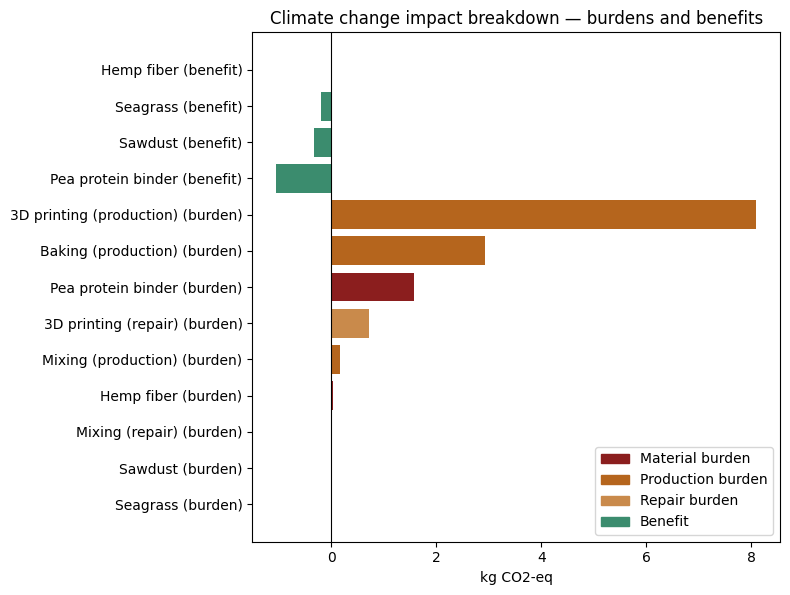

In [81]:
BURDEN_COLORS = {
    "material":   "#8B1E1E",  # deep red
    "production": "#B5651D",  # rust brown
    "repair":     "#C98A4B",  # tan/terracotta
}
BENEFIT_COLOR = "#3B8C6E"

def classify_burden(name):
    if "(production)" in name:
        return "production"
    if "(repair)" in name:
        return "repair"
    return "material"

burden_items = {**material_burden_breakdown, **process_burden_breakdown}
benefit_items = material_benefit_breakdown

burden_series = pd.Series(burden_items).sort_values()
benefit_series = pd.Series(benefit_items).sort_values()

all_labels = [f"{name} (burden)" for name in burden_series.index] + [f"{name} (benefit)" for name in benefit_series.index]
all_values = list(burden_series.values) + list(benefit_series.values)
all_colors = [BURDEN_COLORS[classify_burden(name)] for name in burden_series.index] + [BENEFIT_COLOR] * len(benefit_series)

fig, ax = plt.subplots(figsize=(8, 0.35 * len(all_labels) + 1.5))
ax.barh(all_labels, all_values, color=all_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("kg CO2-eq")
ax.set_title("Climate change impact breakdown — burdens and benefits")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=BURDEN_COLORS["material"],   label="Material burden"),
    Patch(color=BURDEN_COLORS["production"], label="Production burden"),
    Patch(color=BURDEN_COLORS["repair"],     label="Repair burden"),
    Patch(color=BENEFIT_COLOR,               label="Benefit"),
], loc="lower right")

plt.tight_layout()
plt.show()